
  UAVIDS-2025
Avant nettoyage  : 122171 lignes, 23 colonnes
Après nettoyage  : 113952 lignes, 20 colonnes
Lignes supprimées: 8219

  Bruteforce
Avant nettoyage  : 5103 lignes, 45 colonnes
Après nettoyage  : 5097 lignes, 45 colonnes
Lignes supprimées: 6

  DDoS
Avant nettoyage  : 14292 lignes, 45 colonnes
Après nettoyage  : 14292 lignes, 45 colonnes
Lignes supprimées: 0

  DoS
Avant nettoyage  : 14121 lignes, 45 colonnes
Après nettoyage  : 14121 lignes, 45 colonnes
Lignes supprimées: 0

  Evil
Avant nettoyage  : 48 lignes, 45 colonnes
Après nettoyage  : 10 lignes, 45 colonnes
Lignes supprimées: 38

  Fakelanding
Avant nettoyage  : 200 lignes, 45 colonnes
Après nettoyage  : 69 lignes, 45 colonnes
Lignes supprimées: 131

  MITM
Avant nettoyage  : 1164 lignes, 45 colonnes
Après nettoyage  : 208 lignes, 45 colonnes
Lignes supprimées: 956

  Reconnassiance
Avant nettoyage  : 50135 lignes, 45 colonnes
Après nettoyage  : 1152 lignes, 45 colonnes
Lignes supprimées: 48983

  Reply
Avant nettoya

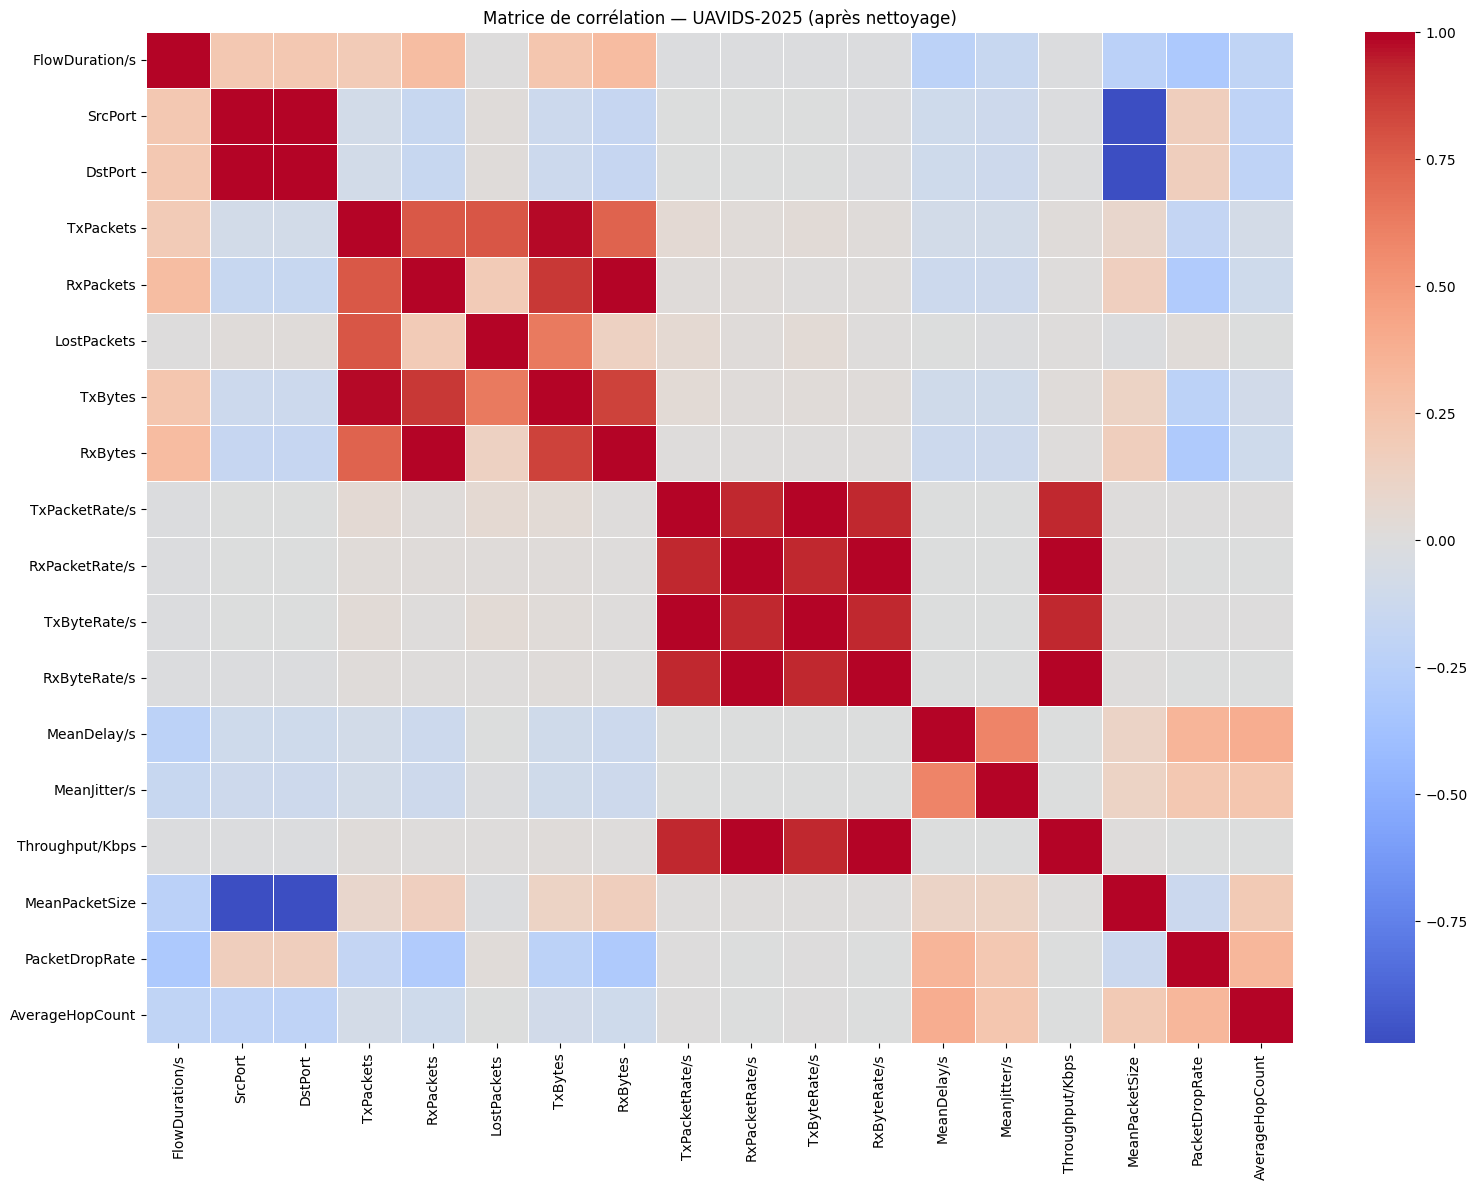


Données nettoyées sauvegardées dans DATASET/Nettoyées/
Résumé exporté dans Rapport/tables/resume_nettoyage.csv
<class 'pandas.DataFrame'>
RangeIndex: 122171 entries, 0 to 122170
Data columns (total 23 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   FlowID           122171 non-null  int64  
 1   FlowDuration/s   122171 non-null  float64
 2   SrcAddr          122171 non-null  str    
 3   SrcPort          122171 non-null  int64  
 4   DstAddr          122171 non-null  str    
 5   DstPort          122171 non-null  int64  
 6   Protocol         122171 non-null  str    
 7   TxPackets        122171 non-null  int64  
 8   RxPackets        122171 non-null  int64  
 9   LostPackets      122171 non-null  int64  
 10  TxBytes          122171 non-null  int64  
 11  RxBytes          122171 non-null  int64  
 12  TxPacketRate/s   122171 non-null  float64
 13  RxPacketRate/s   122171 non-null  float64
 14  TxByteRate/s     122171 non-nul

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ── Rechargement des données
df_uavids         = pd.read_csv(r"C:\Drone_Attack_Similarity_Project\DATASET\Brutes\UAVIDS-2025\UAVIDS-2025.csv")
df_bruteforce     = pd.read_csv(r"C:\Drone_Attack_Similarity_Project\DATASET\Brutes\Each_Attacks_CSV\BruteforceC.csv")
df_ddos           = pd.read_csv(r"C:\Drone_Attack_Similarity_Project\DATASET\Brutes\Each_Attacks_CSV\DDoSC.csv")
df_dos            = pd.read_csv(r"C:\Drone_Attack_Similarity_Project\DATASET\Brutes\Each_Attacks_CSV\DoSC.csv")
df_evil           = pd.read_csv(r"C:\Drone_Attack_Similarity_Project\DATASET\Brutes\Each_Attacks_CSV\EvilC.csv")
df_fakelanding    = pd.read_csv(r"C:\Drone_Attack_Similarity_Project\DATASET\Brutes\Each_Attacks_CSV\FakelandingC.csv")
df_mitm           = pd.read_csv(r"C:\Drone_Attack_Similarity_Project\DATASET\Brutes\Each_Attacks_CSV\MITMC.csv")
df_reconnassiance = pd.read_csv(r"C:\Drone_Attack_Similarity_Project\DATASET\Brutes\Each_Attacks_CSV\ReconnassianceC.csv")
df_reply          = pd.read_csv(r"C:\Drone_Attack_Similarity_Project\DATASET\Brutes\Each_Attacks_CSV\ReplyC.csv")
df_scanning       = pd.read_csv(r"C:\Drone_Attack_Similarity_Project\DATASET\Brutes\Each_Attacks_CSV\ScanningC.csv")
df_normal         = pd.read_csv(r"C:\Drone_Attack_Similarity_Project\DATASET\Brutes\NomralAttacks\Normal.csv")

datasets = {
    "UAVIDS-2025"   : df_uavids,
    "Bruteforce"    : df_bruteforce,
    "DDoS"          : df_ddos,
    "DoS"           : df_dos,
    "Evil"          : df_evil,
    "Fakelanding"   : df_fakelanding,
    "MITM"          : df_mitm,
    "Reconnassiance": df_reconnassiance,
    "Reply"         : df_reply,
    "Scanning"      : df_scanning,
    "Normal"        : df_normal,
}

# ── Chemins de sortie
tables_path    = r"C:\Drone_Attack_Similarity_Project\Rapport\tables"
nettoyees_path = r"C:\Drone_Attack_Similarity_Project\DATASET\Nettoyées"
os.makedirs(tables_path, exist_ok=True)
os.makedirs(nettoyees_path, exist_ok=True)

######### Nettoyage des données ########

datasets_clean = {}

for name, df in datasets.items():

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"Avant nettoyage  : {df.shape[0]} lignes, {df.shape[1]} colonnes")

    # 1. Suppression des colonnes inutiles
    cols_to_drop = [c for c in ["FlowID", "SrcAddr", "DstAddr"] if c in df.columns]
    df = df.drop(columns=cols_to_drop)

    # 2. Suppression des valeurs manquantes
    df = df.dropna()

    # 3. Suppression des doublons
    df = df.drop_duplicates()

    # 4. Suppression des valeurs infinies
    df = df.replace([np.inf, -np.inf], np.nan).dropna()

    print(f"Après nettoyage  : {df.shape[0]} lignes, {df.shape[1]} colonnes")
    print(f"Lignes supprimées: {datasets[name].shape[0] - df.shape[0]}")

    datasets_clean[name] = df

# ── Résumé du nettoyage
print(f"\n{'='*50}")
print(f"{'Dataset':<18} {'Avant':>8} {'Après':>8} {'Supprimées':>12}")
print(f"{'='*50}")
for name in datasets.keys():
    avant = datasets[name].shape[0]
    apres = datasets_clean[name].shape[0]
    print(f"{name:<18} {avant:>8} {apres:>8} {avant - apres:>12}")

######### Sauvegarde des données nettoyées ########

for name, df in datasets_clean.items():
    filename = name.replace("-", "_").replace("/", "_")
    df.to_csv(f"{nettoyees_path}\\{filename}_clean.csv", index=False)

# Export résumé dans tables/
resume = pd.DataFrame([
    {
        "Dataset"          : name,
        "Lignes_avant"     : datasets[name].shape[0],
        "Lignes_apres"     : datasets_clean[name].shape[0],
        "Lignes_supprimees": datasets[name].shape[0] - datasets_clean[name].shape[0],
        "Colonnes_apres"   : datasets_clean[name].shape[1],
    }
    for name in datasets.keys()
])
resume.to_csv(f"{tables_path}\\resume_nettoyage.csv", index=False)

print("\n Données nettoyées sauvegardées dans DATASET/Nettoyées/")
print("Résumé exporté dans Rapport/tables/resume_nettoyage.csv")